c:\Users\rohan\Documents\ELEC391\robot-piano-player\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


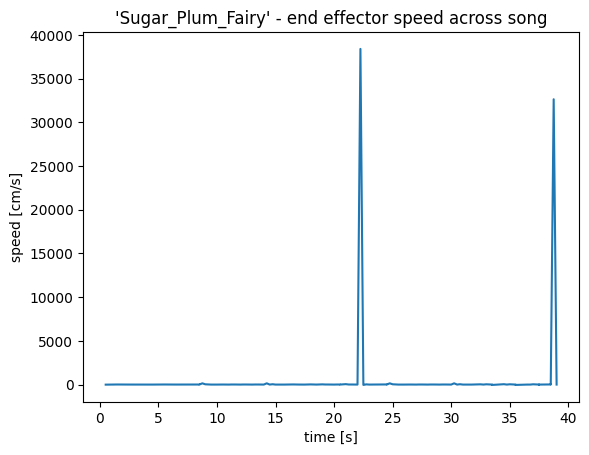

[Note(start=0.000000, end=0.186979, pitch=40, velocity=80), Note(start=0.500000, end=0.624479, pitch=40, velocity=80), Note(start=0.500000, end=0.624479, pitch=43, velocity=80), Note(start=0.500000, end=0.624479, pitch=47, velocity=80), Note(start=1.000000, end=1.186979, pitch=40, velocity=80), Note(start=1.500000, end=1.624479, pitch=54, velocity=80), Note(start=1.500000, end=1.624479, pitch=36, velocity=80), Note(start=1.500000, end=1.624479, pitch=42, velocity=80), Note(start=1.500000, end=1.624479, pitch=45, velocity=80), Note(start=2.000000, end=2.186979, pitch=40, velocity=80), Note(start=2.500000, end=2.624479, pitch=55, velocity=80), Note(start=2.500000, end=2.624479, pitch=37, velocity=80), Note(start=2.500000, end=2.624479, pitch=46, velocity=80), Note(start=3.000000, end=3.186979, pitch=40, velocity=80), Note(start=3.500000, end=3.624479, pitch=36, velocity=80), Note(start=3.500000, end=3.624479, pitch=45, velocity=80), Note(start=4.000000, end=4.186979, pitch=40, velocity=8

In [1]:
# ------------------------ PACKAGE IMPORTS ------------------------
import pretty_midi
import matplotlib.pyplot as plt
import importlib

# Custom Modules - must reload for module changes to reflect properly
import midi_utils
import speed_utils
import pathFinding
importlib.reload(midi_utils) 
importlib.reload(speed_utils) 


ROBOT_FINGERS = [
    # Example: A 5-finger comb design
    {'id': 0, 'offset': 0.0, 'type': 'w'},  
    {'id': 1, 'offset': 1.0, 'type': 'b'}, 
    {'id': 2, 'offset': 2.0, 'type': 'w'}, 
    {'id': 3, 'offset': 3.0, 'type': 'b'},  
    {'id': 4, 'offset': 4.0, 'type': 'w'},
]



# ------------------------ CONSTANTS ------------------------
KEYS_IN_KEYBOARD = 37
PITCHES_IN_OCTAVE = 12

# song_name = "Megalovania"
song_name = "Sugar_Plum_Fairy"

def get_octave(pitch):
    return int(pitch / PITCHES_IN_OCTAVE) - 1

"""
| Octave | C  | C#/Db | D  | D#/Eb | E  | F  | F#/Gb | G  | G#/Ab  | A  | A#/Bb  | B  |
|--------|----|-------|----|-------|----|----|-------|----|--------|----|--------|----|
| -1     | 0  | 1     | 2  | 3     | 4  | 5  | 6     | 7  | 8      | 9  | 10     | 11 |
| 0      | 12 | 13    | 14 | 15    | 16 | 17 | 18    | 19 | 20     | 21 | 22     | 23 |
| 1      | 24 | 25    | 26 | 27    | 28 | 29 | 30    | 31 | 32     | 33 | 34     | 35 |
| 2      | 36 | 37    | 38 | 39    | 40 | 41 | 42    | 43 | 44     | 45 | 46     | 47 |
| 3      | 48 | 49    | 50 | 51    | 52 | 53 | 54    | 55 | 56     | 57 | 58     | 59 |
| 4      | 60 | 61    | 62 | 63    | 64 | 65 | 66    | 67 | 68     | 69 | 70     | 71 |
| 5      | 72 | 73    | 74 | 75    | 76 | 77 | 78    | 79 | 80     | 81 | 82     | 83 |
| 6      | 84 | 85    | 86 | 87    | 88 | 89 | 90    | 91 | 92     | 93 | 94     | 95 |
| 7      | 96 | 97    | 98 | 99    |100 |101 |102    |103 |104     |104 |106     |107 |
| 8      |108 |109    |110 |111    |112 |113 |114    |115 |116     |117 |118     |119 |
| 9      |120 |121    |122 |123    |124 |125 |126    |127 | -      | -  | -      | -  |
"""

# Make sure that MIDI file has just a single track or otherwise do some preprocessing
notes = midi_utils.midi_to_notes(song_name)
notes = midi_utils.fit_song_into_keyboard(notes)
notes = midi_utils.make_song_staccato(notes, note_length=0.5)

midi_utils.notes_to_midi(notes, filename=f"songs/{song_name}_edit.mid")

# Extract pitches
pitches = [note.pitch for note in notes]
highest_pitch = max(pitches)
lowest_pitch  = min(pitches)

# Find lowest note and highest to make sure that the song fits on a keyboard
assert (highest_pitch - lowest_pitch < KEYS_IN_KEYBOARD)

# 47 - good for Megalovania 
# 
left_hand_notes, right_hand_notes = midi_utils.seperate_left_right(notes, PITCH_SEPARATION=47)

left_pitches  = [note.pitch for note in left_hand_notes]
right_pitches = [note.pitch for note in right_hand_notes]

# Ensures that left hand will not need to move
assert (max(left_pitches) - min(left_pitches) <= PITCHES_IN_OCTAVE)
t, speed_plt = speed_utils.calc_speed(right_hand_notes)

plt.plot(t, speed_plt)
plt.title(f"'{song_name}' - end effector speed across song")
plt.ylabel("speed [cm/s]")
plt.xlabel("time [s]")
plt.show()

print(notes)

[{'id': 0, 'offset': 6.84, 'type': 'w'}, {'id': 1, 'offset': 5.699999999999999, 'type': 'b'}, {'id': 2, 'offset': 4.56, 'type': 'w'}, {'id': 3, 'offset': 3.42, 'type': 'b'}, {'id': 4, 'offset': 2.28, 'type': 'w'}]
Found 124 bass notes and 82 melody notes.
Running pathfinding algorithm on Right Hand...
Path found generating C code...
✅ Successfully saved C array to 'robot_schedule.h'!


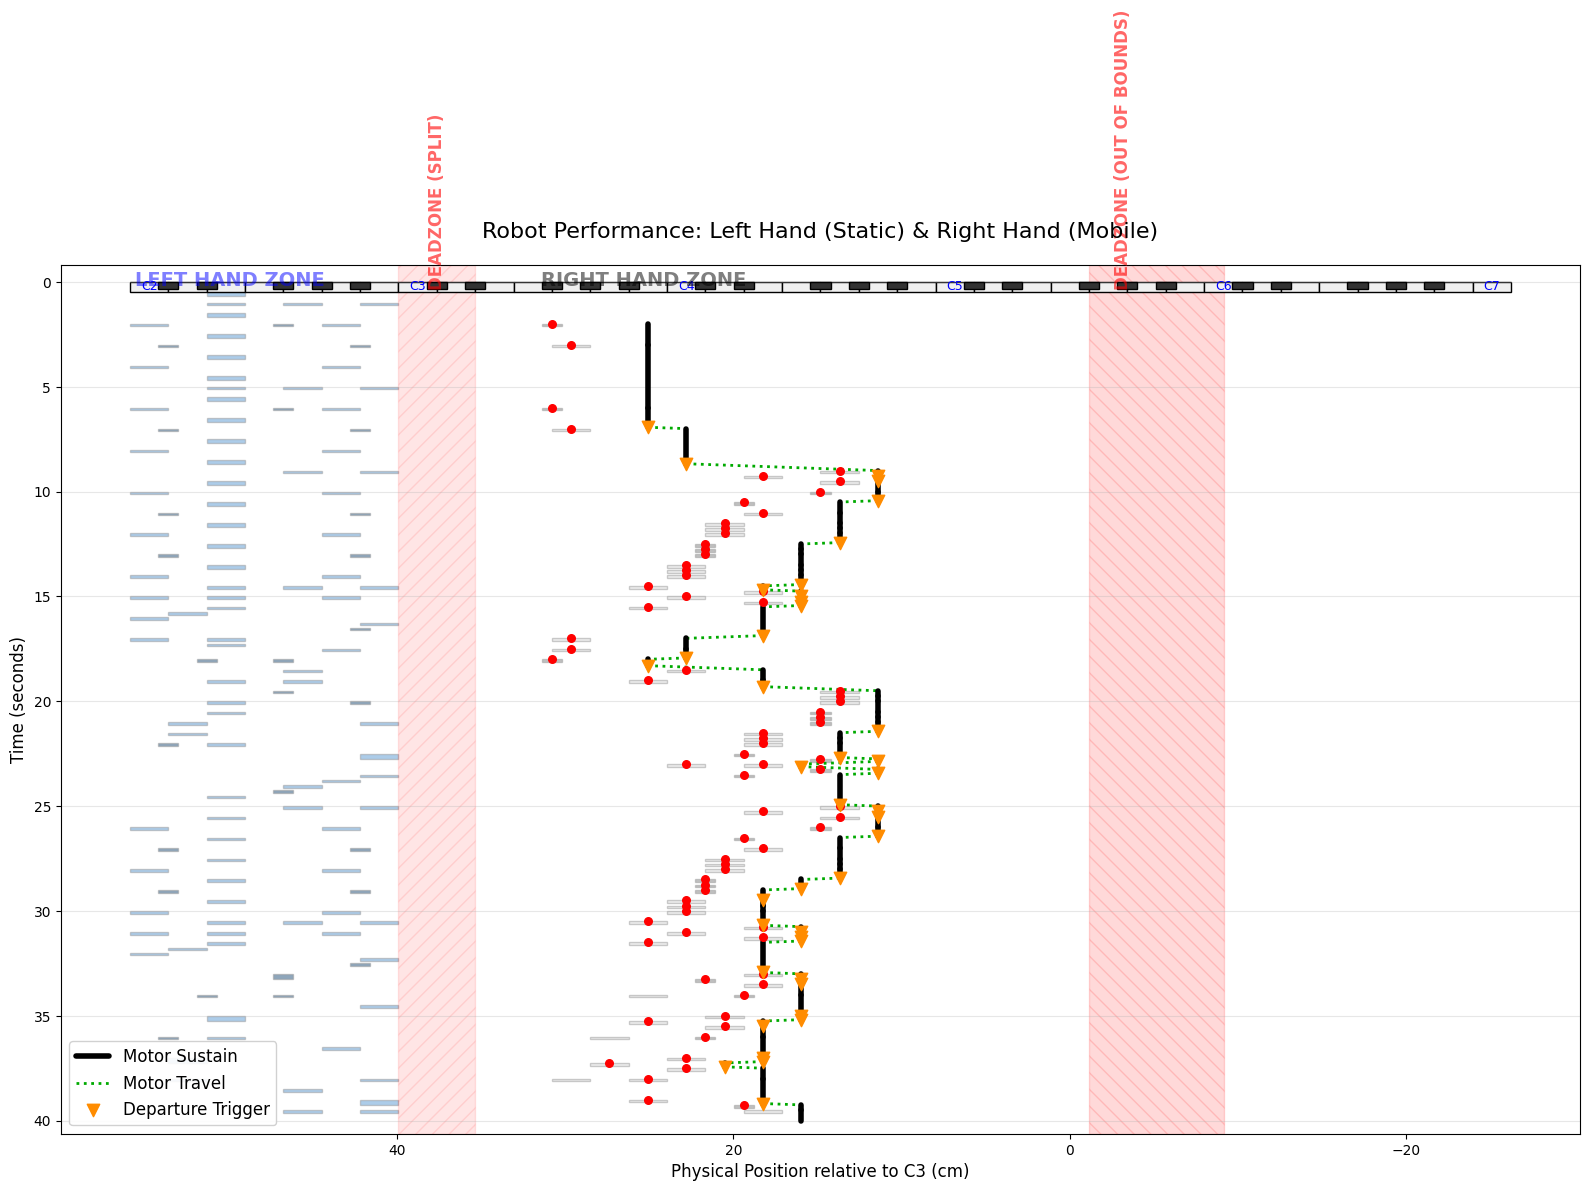

In [2]:
print(pathFinding.ROBOT_FINGERS)

#right_hand_notes = [n for n in notes if n.pitch >= pathFinding.SPLIT_POINT]
#left_hand_notes = [n for n in notes if n.pitch < pathFinding.SPLIT_POINT]

right_hand_notes = [n for n in notes if pathFinding.RH_MIN_PITCH <= n.pitch <= pathFinding.RH_MAX_PITCH]
left_hand_notes = [n for n in notes if n.pitch <= pathFinding.LH_MAX_PITCH]

print(f"Found {len(left_hand_notes)} bass notes and {len(right_hand_notes)} melody notes.")

print("Running pathfinding algorithm on Right Hand...")
rh_times, rh_path_cm = pathFinding.find_best_time_path(right_hand_notes)

if not rh_times:
    print("WARNING: No valid path found! The chord might be physically impossible to span.")
else:
    # 4. Generate the Unified 32-bit C Schedule
    print("Path found generating C code...")
    c_code_output = pathFinding.generate_c_command_array(
        left_notes=left_hand_notes,
        right_notes=right_hand_notes,
        right_times=rh_times,
        right_path_cm=rh_path_cm,
        right_config= pathFinding.ROBOT_FINGERS,
        left_config= pathFinding.LEFT_FINGERS
    )
    
with open("robot_schedule.h", "w") as f:
    f.write(c_code_output)
print("✅ Successfully saved C array to 'robot_schedule.h'!")

pathFinding.plot_robot_performance(
        all_notes=notes, 
        rh_times=rh_times, 
        rh_path_cm=rh_path_cm, 
        right_config=pathFinding.ROBOT_FINGERS
    )

